In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import requests
from sklearn.preprocessing import (OrdinalEncoder, LabelEncoder, OneHotEncoder,
    KBinsDiscretizer, Binarizer, StandardScaler, MinMaxScaler,
    MaxAbsScaler, RobustScaler, Normalizer, FunctionTransformer, PowerTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer, MissingIndicator

##  Step 1: Project Planning & Problem Framing

### Short Notes

**What is Data Analysis?**
Data analysis means collecting raw data and finding useful patterns or insights from it.
We clean it, explore it and make it ready for decision making or predictions.
Example — An e-commerce company wants to know which customers are likely to buy again, so they analyze past purchase data.




# Step 2: Data Import and Understanding

## You are given:

- **customers.csv** – customer demographics and IDs  
- **transactions.json** – transaction records  
- **products.sql** – product info table (import using SQLite)  
- **API:** https://dummyjson.com/users – for additional user details  

---

## Perform

- Load all datasets (CSV, JSON, SQL, API)
- Merge them using relevant keys (`customer_id`, `product_id`)
- Explore the combined dataset using:
  - `.info()`
  - `.describe()`
  - `.head()`

In [47]:
# importing csv dataset

df_csv = pd.read_csv("customers.csv")
print(df_csv.head())

   customer_id    name   age  gender     city    income
0          101  Bhavna  64.0    Male   Indore  212240.0
1          102   Dhruv  29.0  Female    Patna  188819.0
2          103    Alok  33.0    Male  Chennai  106396.0
3          104   Omkar  41.0    Male   Jaipur  137692.0
4          105   Nisha  36.0  Female    Patna  244764.0


In [48]:
# importing json dataset

df_json = pd.read_json("transactions.json")
print(df_json.head())

  transaction_id  customer_id product_id  amount payment_mode       date  \
0          T0001          519       P018    1245         Cash 2025-05-21   
1          T0002          272       P014    1396  Credit Card 2025-05-15   
2          T0003          400       P019    1099  Credit Card 2024-08-13   
3          T0004          273       P009    1198         Cash 2024-10-22   
4          T0005          216       P019    4396  Net Banking 2025-06-07   

   quantity  
0         5  
1         4  
2         1  
3         2  
4         4  


In [49]:
# importing sql dataset

conn = sqlite3.connect(":memory:")
with open("products.sql", "r") as f:
    sql_script = f.read()
conn.executescript(sql_script)
df_sql = pd.read_sql_query("SELECT * FROM products", conn)
print(df_sql.head())

  product_id       product_name     category  price  stock
0       P001          Earphones  Electronics    499     50
1       P002  Bluetooth Speaker        Audio    699     40
2       P003        Smart Watch     Wearable   1299     25
3       P004           Keyboard     Computer    899     60
4       P005         Headphones        Audio   1999     30


In [50]:
# API data (commented out - optional)
url = "https://dummyjson.com/users"
api = requests.get(url).json()
api_users = pd.json_normalize(api['users'])

In [51]:
df = df_json.merge(df_sql, on="product_id", how="left")
df = df.merge(df_csv, on="customer_id", how="left")
df.replace(["None","none","NULL","null","NaN","nan","N/A","n/a"," ","-"], np.nan, inplace=True)

print(df.shape)
df.head()

(1000, 16)


,transaction_id,customer_id,product_id,amount,payment_mode,date,quantity,product_name,category,price,stock,name,age,gender,city,income
0,T0001,519,P018,1245,Cash,2025-05-21,5,Cable Organizer,Computer,249,100,Ramesh,49.0,Female,Bengaluru,NaN
1,T0002,272,P014,1396,Credit Card,2025-05-15,4,Mini Fan,Home,349,90,Nikhil,NaN,Female,Kolkata,182697.0
2,T0003,400,P019,1099,Credit Card,2024-08-13,1,Wireless Charger,Electronics,1099,30,Rohini,24.0,Female,Mumbai,33696.0
3,T0004,273,P009,1198,Cash,2024-10-22,2,Mouse,Computer,599,80,Sagar,45.0,Female,Indore,158557.0
4,T0005,216,P019,4396,Net Banking,2025-06-07,4,Wireless Charger,Electronics,1099,30,Rohini,26.0,Female,Visakhapatnam,219657.0


In [52]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1000 non-null   object        
 1   customer_id     1000 non-null   int64         
 2   product_id      1000 non-null   object        
 3   amount          1000 non-null   int64         
 4   payment_mode    1000 non-null   object        
 5   date            1000 non-null   datetime64[ns]
 6   quantity        1000 non-null   int64         
 7   product_name    1000 non-null   object        
 8   category        1000 non-null   object        
 9   price           1000 non-null   int64         
 10  stock           1000 non-null   int64         
 11  name            1000 non-null   object        
 12  age             951 non-null    float64       
 13  gender          1000 non-null   object        
 14  city            1000 non-null   object        
 15  incom

# Step 3: Exploratory Data Analysis (EDA)

Perform EDA in three stages:

## Univariate Analysis

- Visualize the distribution of numerical columns using histograms  
- Identify skewed variables  
- Use Pandas Profiling for automated insights 

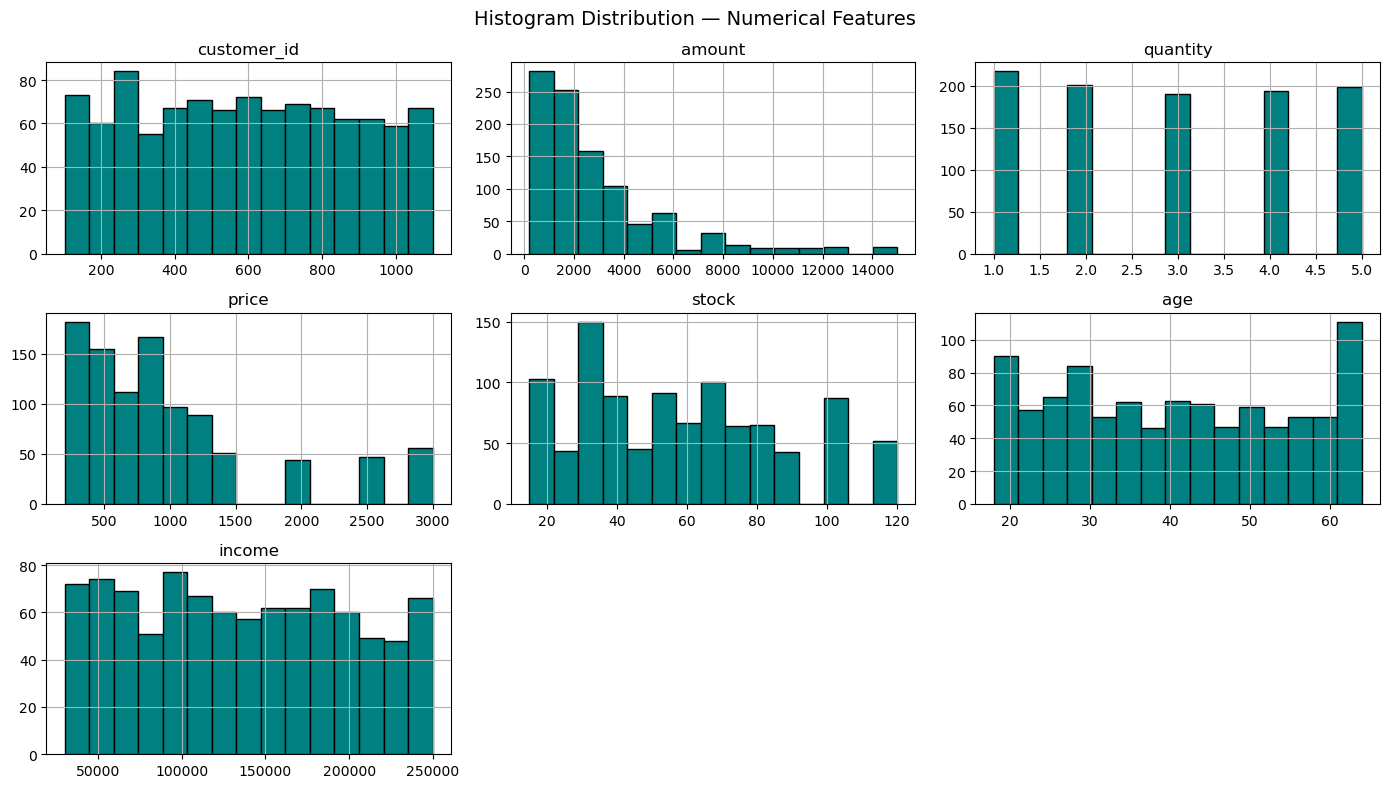

In [53]:
# univariate analysis
# Visualize the distribution of numerical columns using histograms

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numerical_cols].hist(bins=15, figsize=(14, 8), color='teal', edgecolor='black')
plt.suptitle("Histogram Distribution — Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

In [54]:
# identify skewed variables
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print("Skewness of numerical columns:")
print(skewness)

Skewness of numerical columns:
amount         2.044237
price          1.355722
stock          0.441740
income         0.091734
age            0.091480
quantity       0.040258
customer_id    0.033707
dtype: float64


## Bivariate Analysis

- Correlate numerical features with the target column (`purchased = 1 or 0`)  
- Compare means and visualize relationships (e.g., Income vs Purchase) 

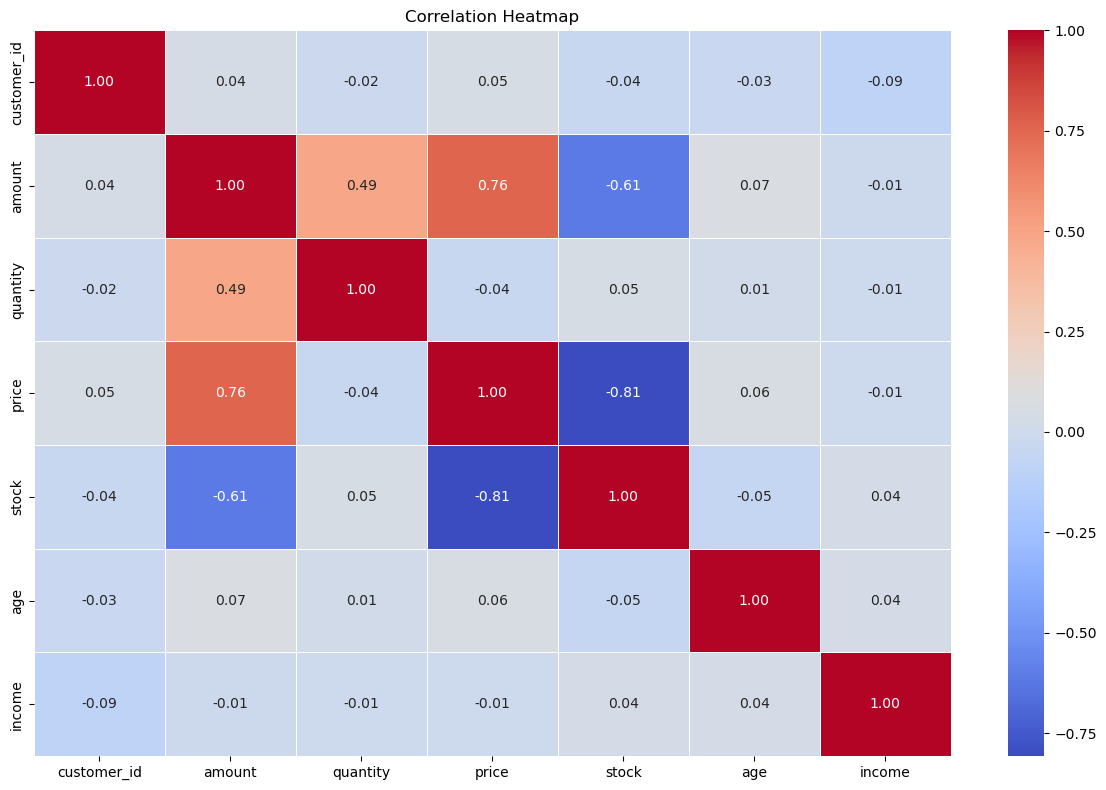

In [55]:
# Bivariate Analysis
# correlation heatmap

plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

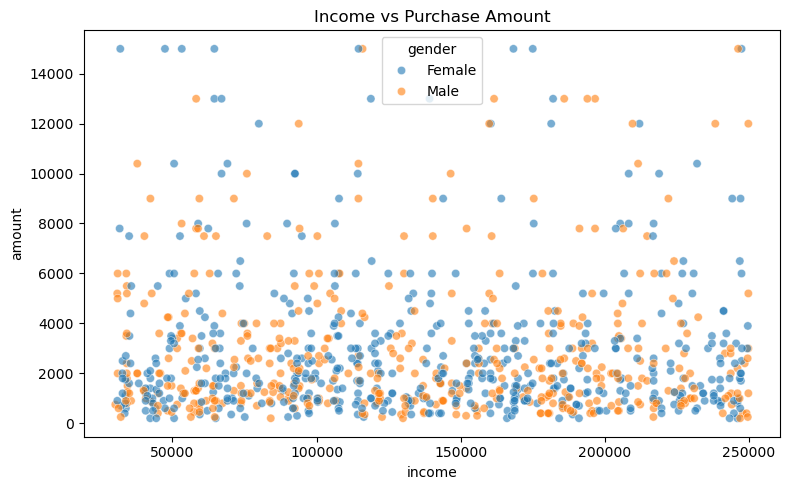

In [56]:
# income vs purchase amount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="income", y="amount", hue="gender", alpha=0.6)
plt.title("Income vs Purchase Amount")
plt.tight_layout()
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_12024\249932503.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="purchased", y="income", palette="Set2")


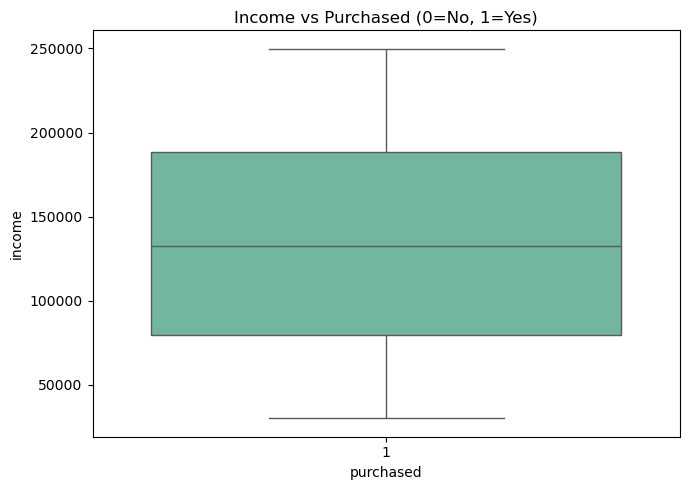

In [57]:
# compare means: income vs purchased
purchased_customers = set(df_json["customer_id"].unique())
df["purchased"] = df["customer_id"].apply(lambda x: 1 if x in purchased_customers else 0)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="purchased", y="income", palette="Set2")
plt.title("Income vs Purchased (0=No, 1=Yes)")
plt.tight_layout()
plt.show()

## Multivariate Analysis

- Use pairplots, heatmaps, or grouped statistics to explore multiple feature relationships  


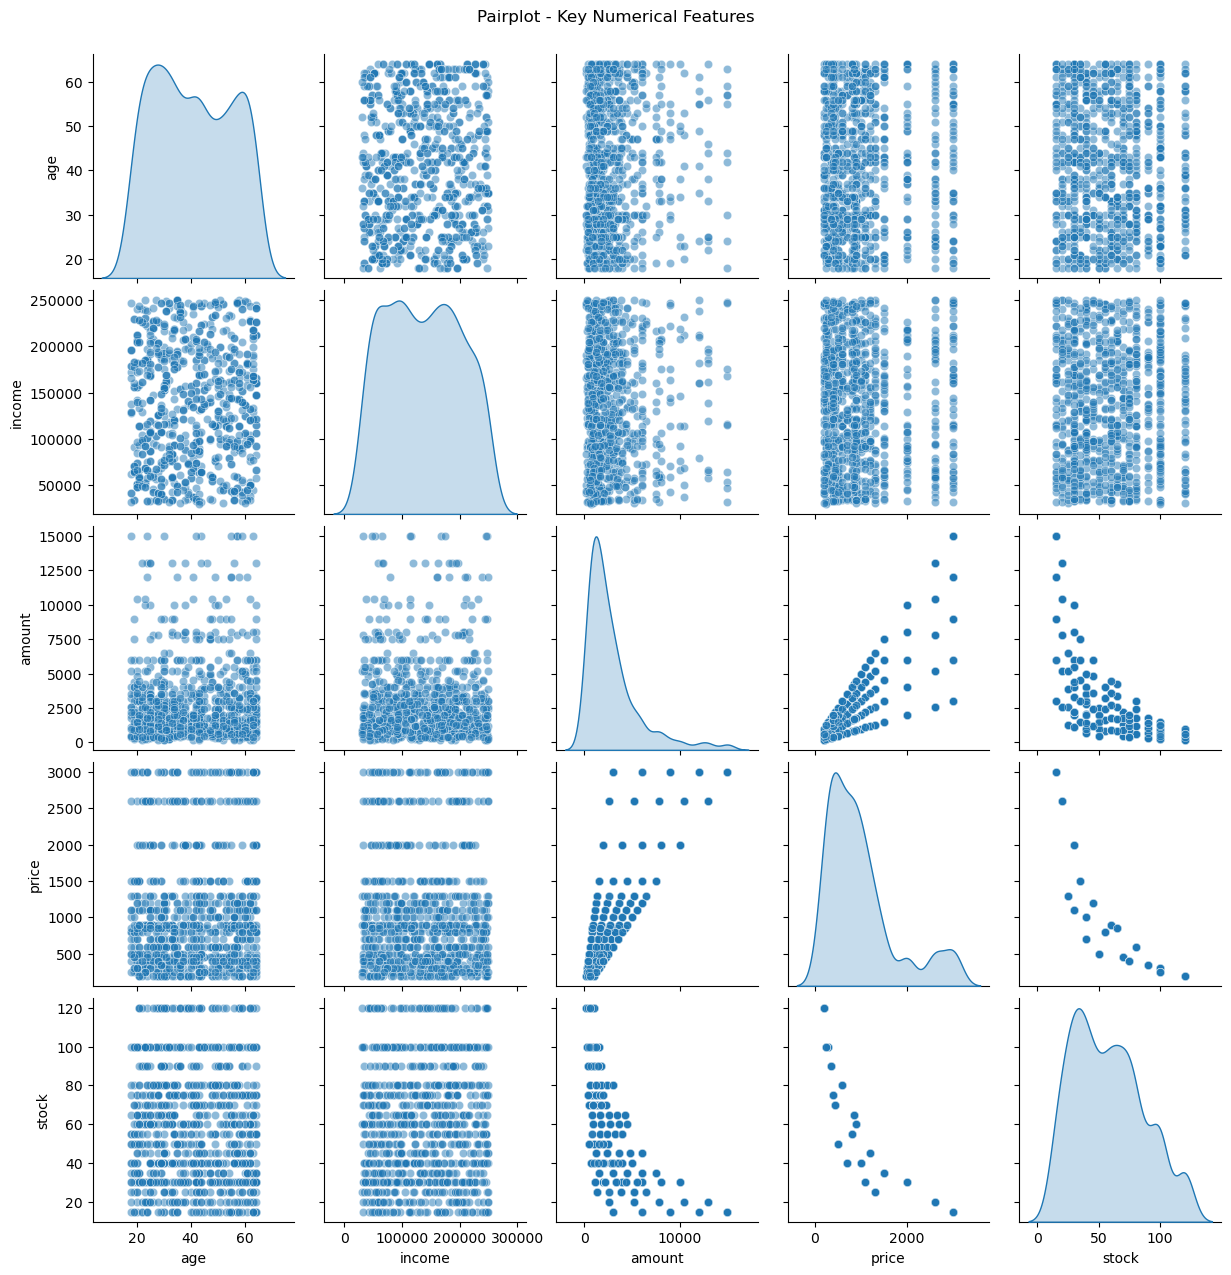

In [58]:
# multivariate analysis
# pairplot on key numerical features

sns.pairplot(df[["age","income","amount","price","stock"]].dropna(), diag_kind="kde", plot_kws={"alpha":0.5})
plt.suptitle("Pairplot - Key Numerical Features", y=1.02)
plt.show()

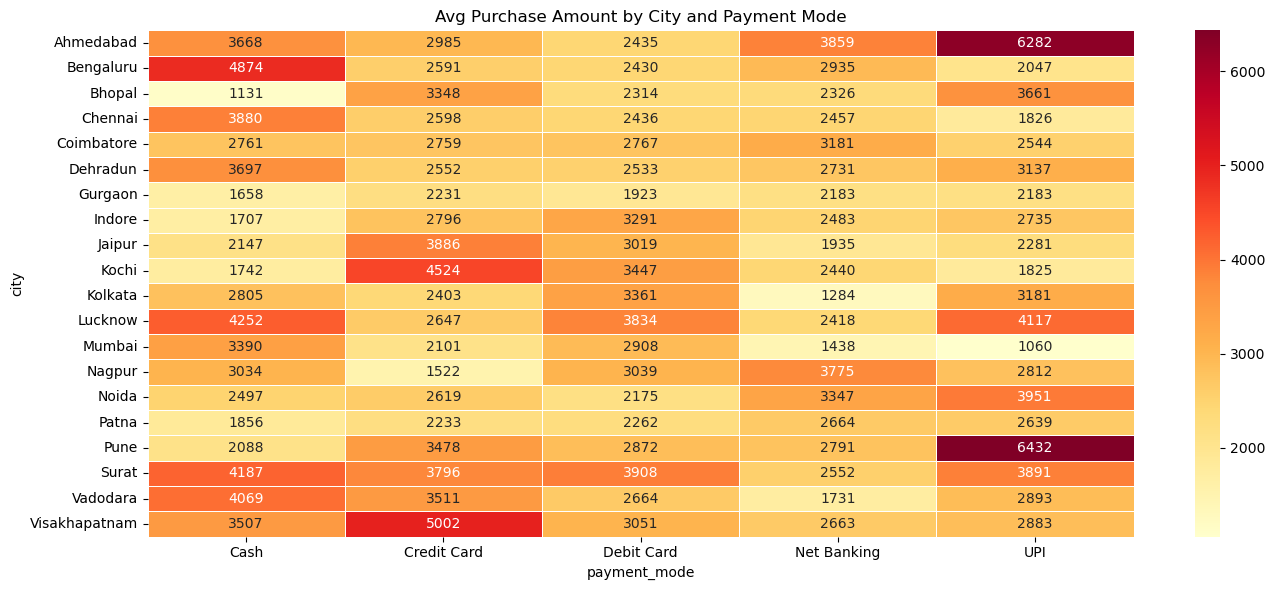

In [59]:
# grouped statistics: avg amount by city and payment_mode

grouped = df.groupby(["city","payment_mode"])["amount"].mean().reset_index()
pivot = grouped.pivot(index="city", columns="payment_mode", values="amount")
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.4)
plt.title("Avg Purchase Amount by City and Payment Mode")
plt.tight_layout()
plt.show()

# Step 4: Handling Missing Data

Use different imputation techniques:

- **Simple Imputer**: for numerical and categorical missing values  
- **Most Frequent Imputation**: for mode-based filling  
- **Missing Indicator + Random Sample Imputation**: show how missing flags are used  
- **KNN Imputer**: for multivariate imputation  
- **MICE Algorithm**: demonstrate chained imputation for correlated features  
- **Complete Case Analysis**: drop missing rows as a comparison  

In [60]:
# simple imputer
df_simple = df.copy()

mean_imputer = SimpleImputer(strategy="mean")
median_imputer = SimpleImputer(strategy="median")
frequent_imputer = SimpleImputer(strategy="most_frequent")

df_simple[["gender","city","payment_mode","category"]] = frequent_imputer.fit_transform(df_simple[["gender","city","payment_mode","category"]])
df_simple[["age"]] = mean_imputer.fit_transform(df_simple[["age"]])
df_simple[["income","amount","price","stock"]] = median_imputer.fit_transform(df_simple[["income","amount","price","stock"]])

print("Missing values after Simple Imputer:")
print(df_simple[["age","income","gender","city"]].isnull().sum())

Missing values after Simple Imputer:
age       0
income    0
gender    0
city      0
dtype: int64


In [61]:
# missing indicator and random sample imputation

df_random = df.copy()

def random_sample_imputer(df, col, random_state=42):
    null_count = df[col].isnull().sum()
    if null_count > 0:
        random_value = df[col].dropna().sample(n=null_count, replace=True, random_state=random_state).values
        df_ = df.copy()
        df_.loc[df_[col].isnull(), col] = random_value
        return df_
    return df

miss_ind = MissingIndicator(features='missing-only')
miss_ind_array = miss_ind.fit_transform(df_random[["age","income"]])
miss_ind_df = pd.DataFrame(miss_ind_array, columns=["age_missing","income_missing"])
print(miss_ind_df.sum())

df_random = random_sample_imputer(df_random, "age")
df_random = random_sample_imputer(df_random, "income")
print("Missing after random sample imputation:", df_random[["age","income"]].isnull().sum().sum())

age_missing       49
income_missing    56
dtype: int64
Missing after random sample imputation: 0


In [62]:
# knn imputer

df_knn = df.copy()

id_cols = ["customer_id","transaction_id","product_id","name","date","payment_mode"]
df_knn_dropped = df_knn[id_cols].copy()
df_knn.drop(id_cols, axis=1, inplace=True)

cat_cols = ["gender","city","category","product_name"]
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
df_knn[cat_cols] = oe.fit_transform(df_knn[cat_cols].astype(str))

knn = KNNImputer(n_neighbors=10, weights='distance')
df_knn = pd.DataFrame(knn.fit_transform(df_knn), columns=df_knn.columns)

df_knn[cat_cols] = oe.inverse_transform(df_knn[cat_cols].round().clip(0))
df_knn = pd.concat([df_knn_dropped.reset_index(drop=True), df_knn.reset_index(drop=True)], axis=1)

print("KNN Imputer - Missing values remaining:")
print(df_knn.isnull().sum().sum())

KNN Imputer - Missing values remaining:
0


In [63]:
# iterative imputer (MICE)

df_mice = df.copy()

id_cols = ["customer_id","transaction_id","product_id","name","date","payment_mode"]
df_mice_dropped = df_mice[id_cols].copy()
df_mice.drop(id_cols, axis=1, inplace=True)

cat_cols = ["gender","city","category","product_name"]
oe2 = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
df_mice[cat_cols] = oe2.fit_transform(df_mice[cat_cols].astype(str))

mice = IterativeImputer(max_iter=10, random_state=42)
df_mice = pd.DataFrame(mice.fit_transform(df_mice), columns=df_mice.columns)

df_mice[cat_cols] = oe2.inverse_transform(df_mice[cat_cols].round().clip(0))
df_mice = pd.concat([df_mice_dropped.reset_index(drop=True), df_mice.reset_index(drop=True)], axis=1)

print("MICE Imputer - Missing values remaining:")
print(df_mice.isnull().sum().sum())

MICE Imputer - Missing values remaining:
0


In [64]:
# complete case analysis
df_cca = df.copy()

print("Shape BEFORE dropping missing rows:", df_cca.shape)
print("Total missing values:\n", df_cca.isnull().sum())

df_cca = df_cca.dropna()

print("\nShape AFTER dropping missing rows:", df_cca.shape)
print("Total rows dropped:", df.shape[0] - df_cca.shape[0])
print("Total missing values after CCA:\n", df_cca.isnull().sum())

Shape BEFORE dropping missing rows: (1000, 17)
Total missing values:
 transaction_id     0
customer_id        0
product_id         0
amount             0
payment_mode       0
date               0
quantity           0
product_name       0
category           0
price              0
stock              0
name               0
age               49
gender             0
city               0
income            56
purchased          0
dtype: int64

Shape AFTER dropping missing rows: (896, 17)
Total rows dropped: 104
Total missing values after CCA:
 transaction_id    0
customer_id       0
product_id        0
amount            0
payment_mode      0
date              0
quantity          0
product_name      0
category          0
price             0
stock             0
name              0
age               0
gender            0
city              0
income            0
purchased         0
dtype: int64


# Step 5: Outlier Detection & Handling

Apply at least 3 different techniques:

- **Z-score Method**  
- **IQR Method**  
- **Percentile Method**  
- Optionally apply **Winsorization** to cap extreme values  

In [65]:
display(df_mice)

,customer_id,transaction_id,product_id,name,date,payment_mode,amount,quantity,product_name,category,price,stock,age,gender,city,income,purchased
0,519,T0001,P018,Ramesh,2025-05-21,Cash,1245.0,5.0,Cable Organizer,Computer,249.0,100.0,49.000000,Female,Bengaluru,135600.182207,1.0
1,272,T0002,P014,Nikhil,2025-05-15,Credit Card,1396.0,4.0,Mini Fan,Home,349.0,90.0,40.584591,Female,Kolkata,182697.000000,1.0
2,400,T0003,P019,Rohini,2024-08-13,Credit Card,1099.0,1.0,Wireless Charger,Electronics,1099.0,30.0,24.000000,Female,Mumbai,33696.000000,1.0
3,273,T0004,P009,Sagar,2024-10-22,Cash,1198.0,2.0,Mouse,Computer,599.0,80.0,45.000000,Female,Indore,158557.000000,1.0
4,216,T0005,P019,Rohini,2025-06-07,Net Banking,4396.0,4.0,Wireless Charger,Electronics,1099.0,30.0,26.000000,Female,Visakhapatnam,219657.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,707,T0996,P020,Zara,2024-04-07,UPI,2999.0,1.0,Portable SSD,Computer,2999.0,15.0,54.000000,Female,Jaipur,111938.000000,1.0
996,587,T0997,P009,Ananya,2025-06-27,Cash,599.0,1.0,Mouse,Computer,599.0,80.0,39.812922,Female,Surat,115774.000000,1.0
997,768,T0998,P007,Qasim,2024-03-19,UPI,3597.0,3.0,USB-C Hub,Computer,1199.0,45.0,43.000000,Female,Visakhapatnam,98136.000000,1.0
998,780,T0999,P017,Mohit,2025-03-19,Net Banking,597.0,3.0,Screen Protector,Mobile Accessories,199.0,120.0,36.000000,Male,Nagpur,31306.000000,1.0


In [66]:
# Z-Score method
# will use df_mice moving forward

columns = ["age", "income", "amount", "price", "stock"]

def z_score(df, cols):
    threshold = 3
    df_z = df.copy()
    for col in cols:
        mean = df_z[col].mean()
        std = df_z[col].std()
        z = (df_z[col] - mean) / std
        df_z[col + "_z_score"] = z
        df_z = df_z[df_z[col + "_z_score"].abs() <= threshold].copy()
        df_z = df_z.drop(columns=[col + "_z_score"])
    return df_z

df_zscore = z_score(df=df_mice, cols=columns)
print(f"After Z-Score: Records Removed: {len(df_mice) - len(df_zscore)}")
print("Shape:", df_zscore.shape)

After Z-Score: Records Removed: 29
Shape: (971, 17)


In [67]:
# IQR method
def iqr(df, cols):
    df_iqr = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR
        outlier_mask = (df[col] < lower_fence) | (df[col] > upper_fence)
        df_iqr = df_iqr[~outlier_mask]
    return df_iqr

df_IQR = iqr(df=df_mice, cols=columns)

print("After applying IQR")
print(f"Records Removed: {len(df_mice) - len(df_IQR)}")
print("Shape:", df_IQR.shape)

After applying IQR
Records Removed: 134
Shape: (866, 17)


C:\Users\dharm\AppData\Local\Temp\ipykernel_12024\704399553.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_iqr = df_iqr[~outlier_mask]
C:\Users\dharm\AppData\Local\Temp\ipykernel_12024\704399553.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_iqr = df_iqr[~outlier_mask]


In [68]:
# Percentile method

def percentile(df, cols, lower, upper):
    df_perc = df.copy()
    for col in cols:
        lower_bound = df_perc[col].quantile(lower)
        upper_bound = df_perc[col].quantile(upper)
        outlier_mask = (df_perc[col] < lower_bound) | (df_perc[col] > upper_bound)
        df_perc = df_perc[~outlier_mask]
    return df_perc

df_percentile = percentile(df=df_mice, cols=columns, lower=0.05, upper=0.95)

print("After applying Percentile method")
print(f"Records Removed: {len(df_mice) - len(df_percentile)}")
print("Shape:", df_percentile.shape)

After applying Percentile method
Records Removed: 330
Shape: (670, 17)


In [69]:
# Winsorization
def winsorization(df, cols, lower, upper):
    df_win = df.copy()
    for col in cols:
        lower_win = df_win[col].quantile(lower)
        upper_win = df_win[col].quantile(upper)
        df_win[col] = df_win[col].clip(lower=lower_win, upper=upper_win)
    return df_win

df_winsorization = winsorization(df=df_mice, cols=columns, lower=0.05, upper=0.95)

print("After applying Winsorization method")
display(df_winsorization)

After applying Winsorization method


,customer_id,transaction_id,product_id,name,date,payment_mode,amount,quantity,product_name,category,price,stock,age,gender,city,income,purchased
0,519,T0001,P018,Ramesh,2025-05-21,Cash,1245.0,5.0,Cable Organizer,Computer,249.0,100.0,49.000000,Female,Bengaluru,135600.182207,1.0
1,272,T0002,P014,Nikhil,2025-05-15,Credit Card,1396.0,4.0,Mini Fan,Home,349.0,90.0,40.584591,Female,Kolkata,182697.000000,1.0
2,400,T0003,P019,Rohini,2024-08-13,Credit Card,1099.0,1.0,Wireless Charger,Electronics,1099.0,30.0,24.000000,Female,Mumbai,40728.000000,1.0
3,273,T0004,P009,Sagar,2024-10-22,Cash,1198.0,2.0,Mouse,Computer,599.0,80.0,45.000000,Female,Indore,158557.000000,1.0
4,216,T0005,P019,Rohini,2025-06-07,Net Banking,4396.0,4.0,Wireless Charger,Electronics,1099.0,30.0,26.000000,Female,Visakhapatnam,219657.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,707,T0996,P020,Zara,2024-04-07,UPI,2999.0,1.0,Portable SSD,Computer,2999.0,15.0,54.000000,Female,Jaipur,111938.000000,1.0
996,587,T0997,P009,Ananya,2025-06-27,Cash,599.0,1.0,Mouse,Computer,599.0,80.0,39.812922,Female,Surat,115774.000000,1.0
997,768,T0998,P007,Qasim,2024-03-19,UPI,3597.0,3.0,USB-C Hub,Computer,1199.0,45.0,43.000000,Female,Visakhapatnam,98136.000000,1.0
998,780,T0999,P017,Mohit,2025-03-19,Net Banking,597.0,3.0,Screen Protector,Mobile Accessories,199.0,120.0,36.000000,Male,Nagpur,40728.000000,1.0


### We will proceed with df_IQR as it removes true outliers without capping data.

# Step 6: Handling Mixed & Date/Time Variables

- Convert `signup_date` and `last_purchase_date` to datetime  
- Derive new features such as `days_since_last_purchase`  
- Handle mixed variables (like customer IDs embedded with letters)  

In [70]:
# convert date column to datetime and derive features

df_IQR["date"] = pd.to_datetime(df_IQR["date"])

np.random.seed(42)
df_IQR["signup_date"] = pd.to_datetime("2019-01-01") + pd.to_timedelta(np.random.randint(0, 1500, size=len(df_IQR)), unit='D')
df_IQR["last_purchase_date"] = df_IQR["date"]

ref_date = pd.Timestamp("2025-06-30")

df_IQR["days_since_signup"] = (ref_date - df_IQR["signup_date"]).dt.days
df_IQR["days_since_last_purchase"] = (ref_date - df_IQR["last_purchase_date"]).dt.days
df_IQR["purchase_month"] = df_IQR["date"].dt.month
df_IQR["purchase_weekday"] = df_IQR["date"].dt.dayofweek

print(df_IQR[["date","signup_date","days_since_signup","days_since_last_purchase","purchase_month","purchase_weekday"]].head())

        date signup_date  days_since_signup  days_since_last_purchase  \
0 2025-05-21  2022-01-31               1246                        40   
1 2025-05-15  2022-12-30                913                        46   
2 2024-08-13  2021-05-10               1512                       321   
3 2024-10-22  2022-07-18               1078                       251   
4 2025-06-07  2022-02-04               1242                        23   

   purchase_month  purchase_weekday  
0               5                 2  
1               5                 3  
2               8                 1  
3              10                 1  
4               6                 5  


# Step 7: Encoding Categorical Data

Apply multiple encoding techniques:

- **Label Encoding**  
- **One Hot Encoding**  
- **Ordinal Encoding** (for education or satisfaction levels)  

---

## Also show:

- **Encoding Numerical Features** (e.g., binning income groups)  



In [71]:
# Label Encoding

le = LabelEncoder()
df_IQR["gender_encoded"] = le.fit_transform(df_IQR["gender"].astype(str))
df_IQR["payment_mode_encoded"] = le.fit_transform(df_IQR["payment_mode"].astype(str))

display(df_IQR[["gender","gender_encoded","payment_mode","payment_mode_encoded"]].head())

,gender,gender_encoded,payment_mode,payment_mode_encoded
0,Female,0,Cash,0
1,Female,0,Credit Card,1
2,Female,0,Credit Card,1
3,Female,0,Cash,0
4,Female,0,Net Banking,3


In [72]:
# One Hot Encoding

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
cols_ohe = ["city", "category"]
encoded_arr = ohe.fit_transform(df_IQR[cols_ohe])
feature_names = ohe.get_feature_names_out(cols_ohe)

df_ohe = pd.DataFrame(encoded_arr, columns=feature_names, index=df_IQR.index)
df_IQR = pd.concat([df_IQR, df_ohe], axis=1)

print("New columns added:", list(feature_names))
display(df_IQR[cols_ohe + list(feature_names)].head())

New columns added: ['city_Bengaluru', 'city_Bhopal', 'city_Chennai', 'city_Coimbatore', 'city_Dehradun', 'city_Gurgaon', 'city_Indore', 'city_Jaipur', 'city_Kochi', 'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Nagpur', 'city_Noida', 'city_Patna', 'city_Pune', 'city_Surat', 'city_Vadodara', 'city_Visakhapatnam', 'category_Computer', 'category_Electronics', 'category_Home', 'category_Mobile Accessories', 'category_Wearable']


,city,category,city_Bengaluru,city_Bhopal,city_Chennai,city_Coimbatore,city_Dehradun,city_Gurgaon,city_Indore,city_Jaipur,...,city_Patna,city_Pune,city_Surat,city_Vadodara,city_Visakhapatnam,category_Computer,category_Electronics,category_Home,category_Mobile Accessories,category_Wearable
0,Bengaluru,Computer,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,Kolkata,Home,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Mumbai,Electronics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Indore,Computer,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Visakhapatnam,Electronics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [73]:
# Ordinal Encoding for product_name

product_order = [sorted(df_IQR["product_name"].dropna().unique().tolist())]
ord_enc = OrdinalEncoder(categories=product_order, handle_unknown='use_encoded_value', unknown_value=-1)
df_IQR["product_name_encoded"] = ord_enc.fit_transform(df_IQR[["product_name"]])
print(df_IQR[["product_name","product_name_encoded"]].drop_duplicates().sort_values("product_name_encoded"))

         product_name  product_name_encoded
29  Bluetooth Speaker                   0.0
0     Cable Organizer                   1.0
31        Car Charger                   2.0
20          Earphones                   3.0
95         Headphones                   4.0
5            Keyboard                   5.0
88      LED Desk Lamp                   6.0
13       Laptop Stand                   7.0
1            Mini Fan                   8.0
3               Mouse                   9.0
16          Neck Band                  10.0
6         Phone Stand                  11.0
32   Screen Protector                  12.0
8          Smart Band                  13.0
18        Smart Watch                  14.0
11          USB-C Hub                  15.0
7              Webcam                  16.0
2    Wireless Charger                  17.0


In [74]:
# Encoding Numerical Features — Binning income groups

kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df_IQR["income_bin"] = kbd.fit_transform(df_IQR[["income"]]).astype(int)

print("After applying quantile binning on income:")
display(df_IQR[["income","income_bin"]].head())
print(df_IQR["income_bin"].value_counts().sort_index())
print(f"Quantile bin edges: {kbd.bin_edges_[0].round(0)}")

After applying quantile binning on income:


,income,income_bin
0,135600.182207,2
1,182697.000000,2
2,33696.000000,0
3,158557.000000,2
4,219657.000000,3


income_bin
0    216
1    217
2    216
3    217
Name: count, dtype: int64
Quantile bin edges: [ 30192.  87505. 135600. 184676. 249763.]


# Step 8: Feature Scaling

Apply multiple scaling techniques to numeric data:

- **StandardScaler**  
- **MinMaxScaler**  
- **MaxAbsScaler**  
- **RobustScaler**  
- **Normalizer**  

Use the `ColumnTransformer` to apply different transformations simultaneously.


In [75]:
scale_cols = ["age", "income", "amount", "price", "stock",
              "days_since_signup", "days_since_last_purchase"]

# StandardScaler
standardization = StandardScaler()
scaled_names = [c + "_stds" for c in scale_cols]
df_IQR[scaled_names] = standardization.fit_transform(df_IQR[scale_cols])
print("StandardScaler:")
display(df_IQR[scaled_names].head())
df_IQR.drop(scaled_names, axis=1, inplace=True)

StandardScaler:


,age_stds,income_stds,amount_stds,price_stds,stock_stds,days_since_signup_stds,days_since_last_purchase_stds
0,0.620396,-0.003286,-0.574232,-1.197872,1.390542,-0.794044,-1.421347
1,0.007615,0.760053,-0.473618,-0.961464,1.011919,-1.578102,-1.383652
2,-1.200018,-1.654938,-0.671515,0.811593,-1.259817,-0.167740,0.344036
3,0.329130,0.368795,-0.605549,-0.370445,0.633297,-1.189605,-0.095739
4,-1.054385,1.359097,1.525345,0.811593,-1.259817,-0.803462,-1.528150


In [76]:
# MinMaxScaler

minmax_scaler = MinMaxScaler()
minmax_names = [c + "_minmax" for c in scale_cols]
df_IQR[minmax_names] = minmax_scaler.fit_transform(df_IQR[scale_cols])
print("MinMax Scaling:")
display(df_IQR[minmax_names].head())
df_IQR.drop(minmax_names, axis=1, inplace=True)

MinMax Scaling:


,age_minmax,income_minmax,amount_minmax,price_minmax,stock_minmax,days_since_signup_minmax,days_since_last_purchase_minmax
0,0.673913,0.480064,0.166137,0.027778,0.789474,0.248833,0.073260
1,0.490969,0.694559,0.190121,0.083333,0.684211,0.026684,0.084249
2,0.130435,0.015958,0.142948,0.500000,0.052632,0.426284,0.587912
3,0.586957,0.584617,0.158672,0.222222,0.578947,0.136758,0.459707
4,0.173913,0.862887,0.666614,0.500000,0.052632,0.246164,0.042125


In [77]:
# MaxAbsScaler

maxabs_scaler = MaxAbsScaler()
maxabs_names = [c + "_maxabs" for c in scale_cols]
df_IQR[maxabs_names] = maxabs_scaler.fit_transform(df_IQR[scale_cols])
print("MaxAbs Scaling:")
display(df_IQR[maxabs_names].head())
df_IQR.drop(maxabs_names, axis=1, inplace=True)

MaxAbs Scaling:


,age_maxabs,income_maxabs,amount_maxabs,price_maxabs,stock_maxabs,days_since_signup_maxabs,days_since_last_purchase_maxabs
0,0.765625,0.542915,0.191686,0.124562,0.833333,0.525295,0.073260
1,0.634134,0.731481,0.214935,0.174587,0.750000,0.384907,0.084249
2,0.375000,0.134912,0.169207,0.549775,0.250000,0.637437,0.587912
3,0.703125,0.634830,0.184450,0.299650,0.666667,0.454469,0.459707
4,0.406250,0.879462,0.676828,0.549775,0.250000,0.523609,0.042125


In [78]:
# RobustScaler

robust_scaler = RobustScaler()
robust_names = [c + "_robust" for c in scale_cols]
df_IQR[robust_names] = robust_scaler.fit_transform(df_IQR[scale_cols])
print("Robust Scaling:")
display(df_IQR[robust_names].head())
df_IQR.drop(robust_names, axis=1, inplace=True)

Robust Scaling:


,age_robust,income_robust,amount_robust,price_robust,stock_robust,days_since_signup_robust,days_since_last_purchase_robust
0,0.386988,0.000003,-0.215920,-0.750000,1.00,-0.458899,-0.801794
1,0.021101,0.484685,-0.143947,-0.583333,0.75,-0.934954,-0.780269
2,-0.699968,-1.048713,-0.285510,0.666667,-0.75,-0.078628,0.206278
3,0.213075,0.236256,-0.238322,-0.166667,0.50,-0.699071,-0.044843
4,-0.613012,0.865047,1.285987,0.666667,-0.75,-0.464618,-0.862780


In [79]:
# Normalizer

normalizer = Normalizer()
norm_names = [c + "_norm" for c in scale_cols]
df_IQR[norm_names] = normalizer.fit_transform(df_IQR[scale_cols])
print("Normalizer:")
display(df_IQR[norm_names].head())
df_IQR.drop(norm_names, axis=1, inplace=True)

Normalizer:


,age_norm,income_norm,amount_norm,price_norm,stock_norm,days_since_signup_norm,days_since_last_purchase_norm
0,0.000361,0.999914,0.009181,0.001836,0.000737,0.009188,0.000295
1,0.000222,0.999956,0.007641,0.001910,0.000493,0.004997,0.000252
2,0.000711,0.997890,0.032546,0.032546,0.000888,0.044777,0.009506
3,0.000284,0.999940,0.007555,0.003778,0.000505,0.006798,0.001583
4,0.000118,0.999771,0.020008,0.005002,0.000137,0.005653,0.000105


In [80]:
# ColumnTransformer — apply different scalers simultaneously

ct = ColumnTransformer(transformers=[
    ("std",  StandardScaler(),  ["age", "income"]),
    ("mm",   MinMaxScaler(),    ["amount", "price"]),
    ("rb",   RobustScaler(),    ["stock", "days_since_signup", "days_since_last_purchase"])
], remainder="passthrough")

ct_result = ct.fit_transform(df_IQR[scale_cols])
print("ColumnTransformer output shape:", ct_result.shape)
print("StandardScaler → age, income | MinMax → amount, price | RobustScaler → stock, days")

ColumnTransformer output shape: (866, 7)
StandardScaler → age, income | MinMax → amount, price | RobustScaler → stock, days


# Step 9: Feature Construction & Transformation

- Create new interaction features  
  - e.g., `purchase_per_day = total_purchases / days_since_signup`  

- Apply transformations:
  - **FunctionTransformer** (Log, Square Root, Reciprocal)  
  - **PowerTransformer** (Box-Cox and Yeo-Johnson)  

In [81]:
# Feature Construction — interaction features

ref_date = pd.Timestamp("2025-06-30")
months_since_signup = (ref_date - df_IQR["signup_date"]).dt.days / 30
months_since_signup = months_since_signup.replace(0, 1)

# transaction count per customer
df_IQR["customer_id_clean"] = df_IQR["customer_id"]
txn_count = df_IQR.groupby("customer_id_clean")["transaction_id"].transform("count")
df_IQR["total_purchases"] = txn_count

# purchase_per_day = total spend / days since signup
df_IQR["purchase_per_day"] = df_IQR["amount"] / (df_IQR["days_since_signup"].replace(0, 1))

# avg spend per purchase
df_IQR["avg_spend_per_purchase"] = df_IQR["amount"] / df_IQR["total_purchases"]

# recency score
df_IQR["recency_score"] = 1 / (df_IQR["days_since_last_purchase"] + 1)

print(df_IQR[["total_purchases","purchase_per_day","avg_spend_per_purchase","recency_score"]].head())

   total_purchases  purchase_per_day  avg_spend_per_purchase  recency_score
0                2          0.999197                   622.5       0.024390
1                2          1.529025                   698.0       0.021277
2                2          0.726852                   549.5       0.003106
3                1          1.111317                  1198.0       0.003968
4                4          3.539452                  1099.0       0.041667


In [82]:
# Log Transform

log_transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)
df_IQR["income_log"] = log_transformer.fit_transform(df_IQR[["income"]])
print("Log Transform:")
display(df_IQR[["income","income_log"]].head())
df_IQR.drop("income_log", axis=1, inplace=True)

Log Transform:


,income,income_log
0,135600.182207,11.817473
1,182697.000000,12.115590
2,33696.000000,10.425164
3,158557.000000,11.973876
4,219657.000000,12.299827


In [83]:
# Square Root Transform

sqrt_transformer = FunctionTransformer(func=np.sqrt, inverse_func=np.square)
df_IQR["amount_sqrt"] = sqrt_transformer.fit_transform(df_IQR[["amount"]])
print("Square Root Transform:")
display(df_IQR[["amount","amount_sqrt"]].head())
df_IQR.drop("amount_sqrt", axis=1, inplace=True)

Square Root Transform:


,amount,amount_sqrt
0,1245.0,35.284558
1,1396.0,37.363083
2,1099.0,33.151169
3,1198.0,34.612137
4,4396.0,66.302338


In [84]:
# Reciprocal Transform
reciprocal_transformer = FunctionTransformer(func=lambda x: 1 / (x + 1))
df_IQR["days_since_signup_recip"] = reciprocal_transformer.fit_transform(df_IQR[["days_since_signup"]])
print("Reciprocal Transform:")
display(df_IQR[["days_since_signup","days_since_signup_recip"]].head())
df_IQR.drop("days_since_signup_recip", axis=1, inplace=True)

Reciprocal Transform:


,days_since_signup,days_since_signup_recip
0,1246,0.000802
1,913,0.001094
2,1512,0.000661
3,1078,0.000927
4,1242,0.000805


In [85]:
# Box-Cox Transform

boxcox_transformer = PowerTransformer(method='box-cox')
df_IQR["amount_boxcox"] = boxcox_transformer.fit_transform(df_IQR[["amount"]])
print("Box-Cox Transform:")
display(df_IQR[["amount","amount_boxcox"]].head())
df_IQR.drop("amount_boxcox", axis=1, inplace=True)

Box-Cox Transform:


,amount,amount_boxcox
0,1245.0,-0.395820
1,1396.0,-0.253217
2,1099.0,-0.547578
3,1198.0,-0.443039
4,4396.0,1.368688


In [86]:
# Yeo-Johnson Transform

yeojohnson_transformer = PowerTransformer(method='yeo-johnson')
df_IQR["income_yj"] = yeojohnson_transformer.fit_transform(df_IQR[["income"]])
print("Yeo-Johnson Transform:")
display(df_IQR[["income","income_yj"]].head())
df_IQR.drop("income_yj", axis=1, inplace=True)

Yeo-Johnson Transform:


,income,income_yj
0,135600.182207,0.068241
1,182697.000000,0.778386
2,33696.000000,-1.825264
3,158557.000000,0.422088
4,219657.000000,1.298450


## Perform binning and binarization:

- Equal-width (quantile) binning on `income`  
- Binary conversion of purchase frequency  
  - (`frequent_buyer = 1 if > threshold`)  

In [87]:
# Binning — quantile binning on income

kbd_q = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df_IQR["income_quantile_bin"] = kbd_q.fit_transform(df_IQR[["income"]]).astype(int)
print("Quantile Binning on income:")
display(df_IQR[["income","income_quantile_bin"]].head())
print(f"Quantile bin edges: {kbd_q.bin_edges_[0].round(0)}")

Quantile Binning on income:


,income,income_quantile_bin
0,135600.182207,2
1,182697.000000,2
2,33696.000000,0
3,158557.000000,2
4,219657.000000,3


Quantile bin edges: [ 30192.  87505. 135600. 184676. 249763.]


In [88]:
# Binarization — frequent_buyer flag

threshold = df_IQR["total_purchases"].median()
bin_transform = Binarizer(threshold=threshold)
df_IQR["frequent_buyer"] = bin_transform.fit_transform(df_IQR[["total_purchases"]]).astype(int)
print("Binarization — frequent_buyer (1 if purchases > median):")
display(df_IQR[["total_purchases","frequent_buyer"]].head(10))
print(df_IQR["frequent_buyer"].value_counts())

Binarization — frequent_buyer (1 if purchases > median):


,total_purchases,frequent_buyer
0,2,0
1,2,0
2,2,0
3,1,0
4,4,1
5,2,0
6,1,0
7,2,0
8,2,0
9,2,0


frequent_buyer
0    696
1    170
Name: count, dtype: int64


# Step 10: Final Output

- Export the cleaned, transformed, and feature-engineered dataset to  
  **`processed_customer_data.csv`**  

  ## Final Submission Requirements

- Save preprocessing code as:
  - `feature_pipeline.py` or  
  - `.ipynb`  

---

## Submit a Short Summary

- What techniques were used?  
- What were the biggest issues with the raw data?  
- Which imputation and scaling worked best?  

---

In [89]:
# create target variable: purchased
purchased_customers = set(df_json["customer_id"].unique())
df_IQR["purchased"] = df_IQR["customer_id_clean"].apply(lambda x: 1 if x in purchased_customers else 0)

print("purchased value counts:")
print(df_IQR["purchased"].value_counts())

purchased value counts:
purchased
1    866
Name: count, dtype: int64


In [90]:
# drop non-numeric / id columns before saving

drop_cols = ["name","transaction_id","product_id","product_name","date",
             "signup_date","last_purchase_date","customer_id","customer_id_clean",
             "city","category","gender","payment_mode"]

final_dataset = df_IQR.drop(columns=[c for c in drop_cols if c in df_IQR.columns])
final_dataset = final_dataset.select_dtypes(include=np.number)

final_dataset.to_csv("processed_customer_data.csv", index=False)

print("--- Final Dataset Summary ---")
print("Shape:", final_dataset.shape)
print("Columns:", final_dataset.columns.tolist())
display(final_dataset.head())

--- Final Dataset Summary ---
Shape: (866, 45)
Columns: ['amount', 'quantity', 'price', 'stock', 'age', 'income', 'purchased', 'days_since_signup', 'days_since_last_purchase', 'purchase_month', 'purchase_weekday', 'gender_encoded', 'payment_mode_encoded', 'city_Bengaluru', 'city_Bhopal', 'city_Chennai', 'city_Coimbatore', 'city_Dehradun', 'city_Gurgaon', 'city_Indore', 'city_Jaipur', 'city_Kochi', 'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Nagpur', 'city_Noida', 'city_Patna', 'city_Pune', 'city_Surat', 'city_Vadodara', 'city_Visakhapatnam', 'category_Computer', 'category_Electronics', 'category_Home', 'category_Mobile Accessories', 'category_Wearable', 'product_name_encoded', 'income_bin', 'total_purchases', 'purchase_per_day', 'avg_spend_per_purchase', 'recency_score', 'income_quantile_bin', 'frequent_buyer']


,amount,quantity,price,stock,age,income,purchased,days_since_signup,days_since_last_purchase,purchase_month,...,category_Mobile Accessories,category_Wearable,product_name_encoded,income_bin,total_purchases,purchase_per_day,avg_spend_per_purchase,recency_score,income_quantile_bin,frequent_buyer
0,1245.0,5.0,249.0,100.0,49.000000,135600.182207,1,1246,40,5,...,0.0,0.0,1.0,2,2,0.999197,622.5,0.024390,2,0
1,1396.0,4.0,349.0,90.0,40.584591,182697.000000,1,913,46,5,...,0.0,0.0,8.0,2,2,1.529025,698.0,0.021277,2,0
2,1099.0,1.0,1099.0,30.0,24.000000,33696.000000,1,1512,321,8,...,0.0,0.0,17.0,0,2,0.726852,549.5,0.003106,0,0
3,1198.0,2.0,599.0,80.0,45.000000,158557.000000,1,1078,251,10,...,0.0,0.0,9.0,2,1,1.111317,1198.0,0.003968,2,0
4,4396.0,4.0,1099.0,30.0,26.000000,219657.000000,1,1242,23,6,...,0.0,0.0,17.0,3,4,3.539452,1099.0,0.041667,3,1
